## Sentiment Analysis using Base Machine Learning Model

#### import library dasar dan menampilkan dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('myunp_reviews.csv')
df.head()

,reviewId,content,score
0,878e522e-1a4a-4a0d-bee4-be91e9ffa232,"jujur ribet bgt aplikasinya, lelet, kamera mir...",1
1,b2703f2f-5ec8-437c-a3c0-8718d23b1ae0,"Saran saya, harusnya di uji coba dulu baru di ...",1
2,71c6bbbb-23e0-4591-8bd6-542366bd2a6e,Mengecewakan. Sebaiknya sebelum diterapkan sis...,1
3,2ea804f4-82de-4dbc-b9c4-02feaf1f92d5,"banyak bug tolong diperbaiki minnnnnnn, gabisa...",1
4,e07e779b-6650-4c79-a091-541f56137fdd,ada kesalahan dalam aplikasi yang membuat saya...,1


In [3]:
df.shape

(130, 3)

In [4]:
df.describe()

,score
count,130.000000
mean,1.800000
std,1.491059
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5.000000


#### Cek data

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

,0
reviewId,0
content,0
score,0


In [7]:
df.isnull().sum()

,0
reviewId,0
content,0
score,0


#### Quick EDA

In [8]:
score_counts = df['score'].value_counts().sort_index()
score_counts.head()

,count
score,
1,96
2,7
3,4
4,3
5,20


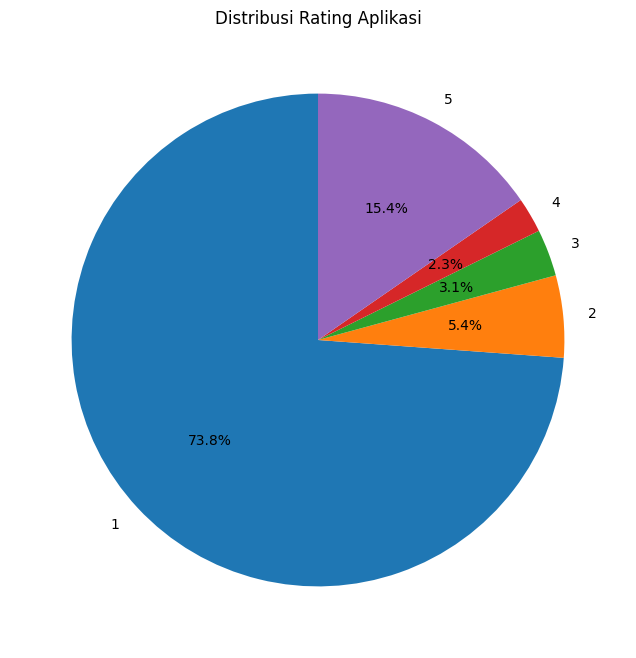

In [9]:
# Membuat pie chart
plt.figure(figsize=(8, 8))
plt.pie(score_counts, labels=score_counts.index, autopct='%1.1f%%', startangle=90)

# Menambahkan judul
plt.title('Distribusi Rating Aplikasi')

# Menampilkan pie chart
plt.show()

#### Teks Prepocessing


In [10]:
df_copy = df.copy()

In [11]:
!pip install nltk

In [12]:
# package kamus besar bahasa indonesia
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.5 MB/s eta 0:00:00


In [13]:
# library yang digunakan untuk teks prepocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [14]:
# Casefolding dan memberihkan data dari simbol yang tidak digunakan

def casefolding_and_cleaning(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z0-9]', ' ', text)
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  text = re.sub(r'#[A-Za-z0-9]+', '', text)
  text = re.sub(r'RT[\s]', '', text)
  text = re.sub(r"http\S+", '', text)
  text = re.sub(r'[0-9]+', '', text)
  text = re.sub(r'[^\w\s]', '', text)
  text = text.replace('\n', ' ')
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = text.strip(' ')
  return text

df_copy['clean_content'] = df_copy['content'].apply(casefolding_and_cleaning)
df_copy['clean_content'].head()

,clean_content
0,jujur ribet bgt aplikasinya lelet kamera mir...
1,saran saya harusnya di uji coba dulu baru di ...
2,mengecewakan sebaiknya sebelum diterapkan sis...
3,banyak bug tolong diperbaiki minnnnnnn gabisa...
4,ada kesalahan dalam aplikasi yang membuat saya...


In [22]:
# normalisasi
norm = {
    "dgn": "dengan", "gue": "saya", "bgmn": "bagaimana", 'tdk': 'tidak', 'blum': 'belum',
    'mantaaaaaaaappp': 'bagus', 'josss': 'bagus', 'thanks': 'terima kasih', 'fast': 'cepat',
    'dg': 'dengan', 'trims': 'terima kasih', 'brg': 'barang', 'gx': 'tidak',
    'recommended': 'rekomen', 'recomend': 'rekomen', 'good': 'bagus',
    "no": "nomor", "abis": "habis", "masi": "masih", "wts": "jual", "wtt": "tukar",
    "bgt": "banget", "maks": "maksimal", "hp": "handphone", "pdhl": "padahal",
    "jd": "jadi", "gk": "tidak", "lelet": "lambat", "gpp": "tidak apa-apa",
    "gabisa": "tidak bisa", "gak bisa": "tidak bisa", "ga bisa": "tidak bisa", "ga": "tidak",
    "nggak": "tidak", "ngga": "tidak", "minnnnnnn": "admin", "adminnn": "admin",
    "min": "admin", "apps": "aplikasi", "bug": "kesalahan sistem", "ngefoto": "mengambil foto",
    "kali": "sekali", "keluar2": "keluar terus", "absen": "presensi", "ujicoba": "uji coba",
    "uji coba": "uji coba", "developer": "pengembang", "ribet": "rumit",
    "kurang memuaskan": "tidak memuaskan", "susah": "sulit", "banyak bug": "banyak kesalahan sistem",
    "agk": "agak"
}

def normalisasi(str_text):
  for i in norm:
    str_text = str_text.replace(i, norm[i])
  return str_text

df_copy['normalisasi'] = df_copy['clean_content'].apply(lambda x: normalisasi(x))
df_copy['normalisasi'].head()

,normalisasi
0,jujur rumit banget aplikasinya lambat kamera...
1,saran saya harusnya di uji coba dulu baru di ...
2,mengecewakan sebaiknya sebelum diterapkan sis...
3,banyak kesalahan sistem tolong diperbaiki adad...
4,ada kesalahan dalam aplikasi yang membuat saya...


In [23]:
# Removing Stopword
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import nltk

# Unduh stopwords dari nltk
nltk.download('stopwords')

# Gabungkan stopwords bahasa Indonesia (Sastrawi) dan bahasa Inggris (nltk)
factory = StopWordRemoverFactory()
stopwords_indonesia = factory.get_stop_words()
stopwords_english = stopwords.words('english')
combined_stopwords = set(stopwords_indonesia + stopwords_english)

# Fungsi untuk membersihkan teks dan menghapus stopwords
def clean_text_remove_stopwords(text):
    # Check if text is a list and join it into a string if necessary
    if isinstance(text, list):
        text = ' '.join(text)

    # Lowercase teks
    text = text.lower()
    # Hapus angka dan tanda baca
    text = re.sub(r'[^\w\s]', '', text)  # Hapus tanda baca
    text = re.sub(r'\d+', '', text)      # Hapus angka
    # Tokenisasi kata
    words = text.split()
    # Hapus stopwords
    filtered_words = [word for word in words if word not in combined_stopwords]
    # Gabungkan kembali menjadi kalimat
    return ' '.join(filtered_words)

df_copy['after_stopword'] = df_copy['normalisasi'].apply(clean_text_remove_stopwords)

# Hasil
for original, cleaned in zip(df_copy['content'], df_copy['after_stopword']):
    print(f"Teks Asli: {original}")
    print(f"Teks Bersih: {cleaned}\n")

Teks Asli: jujur ribet bgt aplikasinya, lelet, kamera mirror, lokasi sering bgt jauh dari lokasi, kan ga lucu ngulang matkul krn aplikasi sering error gini. mending balik ke e-learning lagi aja min, udh bener pake 1 web aja buat ngumpulin tugas+absen. aslinya mau ngasih bintang -999999, tapi ga ada di opsi.
Teks Bersih: jujur rumit banget aplikasinya lambat kamera mirror lokasi sering banget jauh lokasi kan lucu ngulang matkul krn aplikasi sering error gini mending balik e learning aja admin udh bener pake web aja buat ngumpulin tutidaks presensi aslinya mau ntidaksih bintang opsi

Teks Asli: Saran saya, harusnya di uji coba dulu baru di resmikan. Soalnya ini masa kita mau absen ada yg keluar lah, nggak ke deteksi lah, nggak ke simpanlah, bahkan jadinya terlewat absen nya cuma karena masalah yang berasal dari apk nya. Bukan dari mahasiswa nya.
Teks Bersih: saran harusnya uji coba dulu baru resmikan soalnya masa mau presensi yg keluar lah ngtidakk deteksi lah ngtidakk simpanlah bahkan j

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
# Tokenizing

nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize, word_tokenize

df_copy['tokenized'] = df_copy['after_stopword'].apply(lambda x: nltk.word_tokenize(x))
df_copy['tokenized'].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,tokenized
0,"[jujur, rumit, banget, aplikasinya, lambat, ka..."
1,"[saran, harusnya, uji, coba, dulu, baru, resmi..."
2,"[mengecewakan, sebaiknya, diterapkan, sistem, ..."
3,"[banyak, kesalahan, sistem, diperbaiki, adadmi..."
4,"[kesalahan, aplikasi, membuat, masuk, aplikasi..."


#### Pelabelan Rating (angka) ke Sentimen

dengan teknik VADER (Valence Aware Dictionary and sEntiment Reasoner), Sangat efektif untuk teks informal dan sosial media, cocok untuk analisis sentimen dalam konteks tersebut.

In [25]:
!pip install vaderSentiment

In [26]:
# dengan teknik VADER
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Fungsi untuk analisis sentimen
def analyze_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']

# Terapkan analisis ke dataset
df_copy['sentiment_score'] = df_copy['content'].apply(lambda x: analyze_sentiment(str(x)))

In [27]:
# Klasifikasi sentimen
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_copy['sentiment'] = df_copy['sentiment_score'].apply(classify_sentiment)

In [28]:
# Distribusi sentimen
print(df_copy['sentiment'].value_counts())

# Tampilkan hasil analisis
print(df_copy.head())

sentiment
Neutral     107
Negative     13
Positive     10
Name: count, dtype: int64
                               reviewId  \
0  878e522e-1a4a-4a0d-bee4-be91e9ffa232   
1  b2703f2f-5ec8-437c-a3c0-8718d23b1ae0   
2  71c6bbbb-23e0-4591-8bd6-542366bd2a6e   
3  2ea804f4-82de-4dbc-b9c4-02feaf1f92d5   
4  e07e779b-6650-4c79-a091-541f56137fdd   

                                             content  score  \
0  jujur ribet bgt aplikasinya, lelet, kamera mir...      1   
1  Saran saya, harusnya di uji coba dulu baru di ...      1   
2  Mengecewakan. Sebaiknya sebelum diterapkan sis...      1   
3  banyak bug tolong diperbaiki minnnnnnn, gabisa...      1   
4  ada kesalahan dalam aplikasi yang membuat saya...      1   

                                       clean_content  \
0  jujur ribet bgt aplikasinya  lelet  kamera mir...   
1  saran saya  harusnya di uji coba dulu baru di ...   
2  mengecewakan  sebaiknya sebelum diterapkan sis...   
3  banyak bug tolong diperbaiki minnnnnnn  gabisa...  

#### Ekstrasi fitur/Feature engineering

Pembobotan TF-IDF

In [29]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Pisahkan data menjadi content dan label (sentimen)
x = df_copy['tokenized'].apply(lambda tokens: ' '.join(tokens))  # Join tokens into a single string
y = df_copy['sentiment']

cv = CountVectorizer()
term_fit = cv.fit(x)

print(len(term_fit.vocabulary_))

554


In [30]:
term_fit.vocabulary_

{'jujur': 208,
 'rumit': 435,
 'banget': 43,
 'aplikasinya': 27,
 'lambat': 262,
 'kamera': 212,
 'mirror': 336,
 'lokasi': 278,
 'sering': 466,
 'jauh': 202,
 'kan': 215,
 'lucu': 283,
 'ngulang': 361,
 'matkul': 306,
 'krn': 250,
 'aplikasi': 25,
 'error': 151,
 'gini': 166,
 'mending': 319,
 'balik': 41,
 'learning': 266,
 'aja': 7,
 'admin': 3,
 'udh': 531,
 'bener': 55,
 'pake': 392,
 'web': 544,
 'buat': 85,
 'ngumpulin': 362,
 'tutidaks': 528,
 'presensi': 419,
 'aslinya': 30,
 'mau': 307,
 'ntidaksih': 372,
 'bintang': 78,
 'opsi': 379,
 'saran': 443,
 'harusnya': 177,
 'uji': 532,
 'coba': 100,
 'dulu': 145,
 'baru': 49,
 'resmikan': 432,
 'soalnya': 483,
 'masa': 298,
 'yg': 552,
 'keluar': 233,
 'lah': 259,
 'ngtidakk': 360,
 'deteksi': 116,
 'simpanlah': 477,
 'bahkan': 39,
 'jadinya': 196,
 'terlewat': 509,
 'nya': 375,
 'cuma': 104,
 'masalah': 299,
 'berasal': 58,
 'apk': 23,
 'bukan': 87,
 'mahasiswa': 286,
 'mengecewakan': 322,
 'sebaiknya': 449,
 'diterapkan': 139,
 '

In [31]:
dokumen = term_fit.transform(x)
tfidf_transformer = TfidfTransformer().fit(dokumen)
print(tfidf_transformer.idf_)

[5.18205014 5.18205014 5.18205014 3.57261223 5.18205014 5.18205014
 5.18205014 3.92928717 5.18205014 4.77658503 5.18205014 5.18205014
 5.18205014 5.18205014 5.18205014 5.18205014 5.18205014 5.18205014
 3.23613999 5.18205014 5.18205014 5.18205014 4.77658503 3.31024797
 4.77658503 2.44121012 5.18205014 3.67797275 4.77658503 5.18205014
 5.18205014 5.18205014 4.77658503 5.18205014 5.18205014 5.18205014
 5.18205014 3.1026086  5.18205014 5.18205014 4.48890296 4.08343785
 5.18205014 3.92928717 3.23613999 4.77658503 5.18205014 5.18205014
 5.18205014 4.26575941 5.18205014 5.18205014 5.18205014 5.18205014
 5.18205014 5.18205014 5.18205014 5.18205014 5.18205014 5.18205014
 4.77658503 5.18205014 5.18205014 5.18205014 5.18205014 5.18205014
 5.18205014 5.18205014 5.18205014 5.18205014 4.77658503 5.18205014
 5.18205014 5.18205014 5.18205014 5.18205014 5.18205014 4.26575941
 4.08343785 5.18205014 5.18205014 5.18205014 5.18205014 5.18205014
 5.18205014 4.26575941 4.48890296 4.48890296 4.77658503 4.7765

#### Model training menggunakan Random Forest

In [32]:
# membagi dataset ke data training dan testing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(decode_error='replace', encoding='utf-8')

x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)

In [34]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(91, 449)
(39, 449)
(91,)
(39,)


In [35]:
from sklearn.ensemble import RandomForestClassifier

# Membuat objek model Random Forest
model = RandomForestClassifier()

# Melatih model Random Forest pada data pelatihan
model.fit(x_train, y_train)

RandomForestClassifier()

In [36]:
from sklearn.metrics import accuracy_score, classification_report

# Prediksi pada data uji
y_pred = model.predict(x_test)

# Evaluasi model
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Akurasi: 0.8717948717948718
Classification Report:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         4
     Neutral       0.87      1.00      0.93        34
    Positive       0.00      0.00      0.00         1

    accuracy                           0.87        39
   macro avg       0.29      0.33      0.31        39
weighted avg       0.76      0.87      0.81        39



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Akurasi yang tercapai 87%